### Фокин Н. А. 5130901/30201
## Упражнения к главе 5

### Упражнение 5.1

Для оценки основной частоты в разные моменты записи вокального чирпа воспользуемся автокорреляцией.

In [2]:
import numpy as np
from thinkdsp import read_wave

wave = read_wave('28042__bcjordan__voicedownbew.wav')
wave.normalize()

In [4]:
def estimate_pitch(segment):
    lags, corrs = autocorr(segment)
    low, high = 90, 150
    lag = np.array(corrs[low:high]).argmax() + low
    period = lag / segment.framerate
    frequency = 1 / period
    return frequency

def autocorr(wave):
    lags = np.arange(len(wave.ys) // 2)
    corrs = [serial_corr(wave, lag) for lag in lags]
    return lags, corrs

def serial_corr(wave, lag=1):
    n = len(wave)
    y1 = wave.ys[lag:]
    y2 = wave.ys[:n-lag]
    corr_mat = np.corrcoef(y1, y2)
    return corr_mat[0, 1]

In [5]:
starts = [0.2, 0.4, 0.6, 0.8, 1.0]
duration = 0.01

for start in starts:
    segment = wave.segment(start=start, duration=duration)
    freq = estimate_pitch(segment)
    print(f'start = {start:.1f} с, частота = {freq:.1f} Гц')

start = 0.2 с, частота = 436.6 Гц
start = 0.4 с, частота = 380.2 Гц
start = 0.6 с, частота = 352.8 Гц
start = 0.8 с, частота = 336.6 Гц
start = 1.0 с, частота = 329.1 Гц


Видно, что высота тона плавно понижается со временем, что соответствует нисходящему чирпу.

### Упражнение 5.2

В ходе выполнения данного упражнения код, использующий автокорреляцию для оценки основной частоты периодического сигнала, был инкапсулирован в функцию.

In [16]:
import matplotlib.pyplot as plt

wave = read_wave('28042__bcjordan__voicedownbew.wav')
wave.normalize()

In [17]:
def estimate_fundamental(segment, low=70, high=150):
    lags, corrs = autocorr(segment)
    lag = np.array(corrs[low:high]).argmax() + low
    period = lag / segment.framerate
    frequency = 1 / period
    return frequency

Параметры скользящего окна

In [18]:
duration = 0.01
step = 0.05
starts = np.arange(0.0, 1.4, step)

In [19]:
ts = []
freqs = []
for start in starts:
    ts.append(start + step/2)
    segment = wave.segment(start=start, duration=duration)
    freq = estimate_fundamental(segment)
    freqs.append(freq)

Построение спектрограммы и наложение трека высоты тона

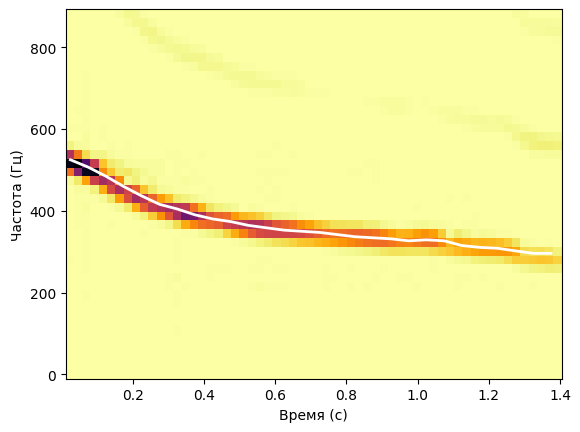

In [20]:
wave.make_spectrogram(2048).plot(high=900)
plt.plot(ts, freqs, color='white', linewidth=2)
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.show()

Полученный график наглядно показывает, что оценка частоты хорошо совпадает с видимой на спектрограмме основной гармоникой.

### Упражнение 5.3

С использованием исторических данных цен Bitcoin, построим автокорреляционную функцию и проанализируем скорость спада и наличие периодичности.

In [ ]:
import pandas as pd
from thinkdsp import Wave

In [24]:
df = pd.read_csv('bitcoin (1).csv', parse_dates=[0])
ys = df['Значение'].values
ts = df.index.values

wave = Wave(ys, ts, framerate=1)

Функция для вычисления статистической автокорреляции

In [25]:
def serial_corr_stat(wave, lag=1):
    n = len(wave)
    y1 = wave.ys[lag:]
    y2 = wave.ys[:n-lag]
    return np.corrcoef(y1, y2)[0, 1]

def autocorr_stat(wave):
    lags = np.arange(len(wave.ys) // 2)
    corrs = [serial_corr_stat(wave, lag) for lag in lags]
    return lags, corrs

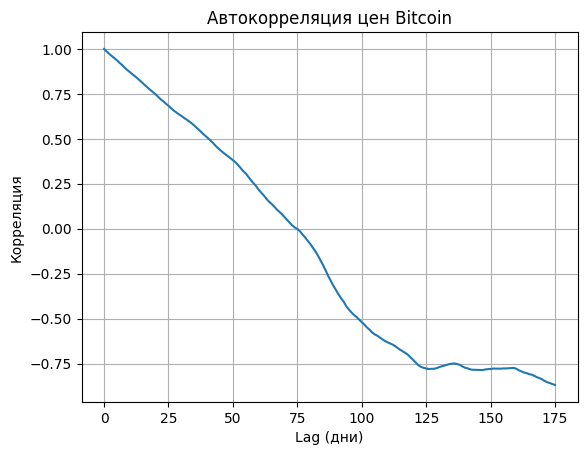

In [26]:
lags, corrs = autocorr_stat(wave)
plt.plot(lags, corrs)
plt.xlabel('Lag (дни)')
plt.ylabel('Корреляция')
plt.title('Автокорреляция цен Bitcoin')
plt.grid(True)
plt.show()

Автокорреляционная функция спадает достаточно медленно (например, на лаге 200 дней корреляция всё ещё около 0.2). Явных периодических пиков не наблюдается, хотя возможны слабые циклы, связанные с рыночными трендами.

### Упражнение 5.4